## **EDA**

In [1]:
import numpy as np
import pandas as pd
import data_profiling
from data_profiling import ProfileReport

df = pd.read_csv('PH_Housing.csv')

# Print all unique columns
df.columns.unique()

Index(['HouseID', 'Description', 'Location', 'Price', 'Bedrooms', 'Bathrooms',
       'Floor Area', 'Land Area', 'Latitude', 'Longitude'],
      dtype='object')

In [2]:
# Drop certain columns that are not needed
df_clean = df.copy()
df_clean.drop(["HouseID"], axis=1, inplace=True)

In [3]:
# Save file as "ph_housing_eda.html"

profile = ProfileReport(df_clean, title='Philippine Housing Profiling Report')
profile.to_file("ph_housing_eda.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 9/9 [00:00<00:00, 176.84it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## **Data Preprocessing**

In [4]:
# Remove observations with missing entries
df_clean = df_clean.dropna()

df_clean.info()
df_clean.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 1320 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Description  1320 non-null   object 
 1   Location     1320 non-null   object 
 2   Price        1320 non-null   float64
 3   Bedrooms     1320 non-null   float64
 4   Bathrooms    1320 non-null   float64
 5   Floor Area   1320 non-null   float64
 6   Land Area    1320 non-null   float64
 7   Latitude     1320 non-null   float64
 8   Longitude    1320 non-null   float64
dtypes: float64(7), object(2)
memory usage: 103.1+ KB


,Price,Bedrooms,Bathrooms,Floor Area,Land Area,Latitude,Longitude
count,1.320000e+03,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000
mean,3.349833e+07,3.600758,2.971970,212.771591,239.427879,14.200741,121.238114
std,1.050834e+08,1.306251,1.856379,235.193660,559.908862,1.848052,1.047671
min,3.000000e+05,1.000000,1.000000,22.000000,27.000000,6.128079,120.228242
25%,5.183808e+06,3.000000,2.000000,66.000000,80.000000,14.359233,120.858456
50%,9.500000e+06,3.000000,3.000000,142.000000,120.000000,14.541971,121.026941
75%,2.500000e+07,4.000000,4.000000,250.000000,220.250000,14.913178,121.074534
max,2.500000e+09,13.000000,43.000000,2200.000000,10000.000000,17.630468,125.739679


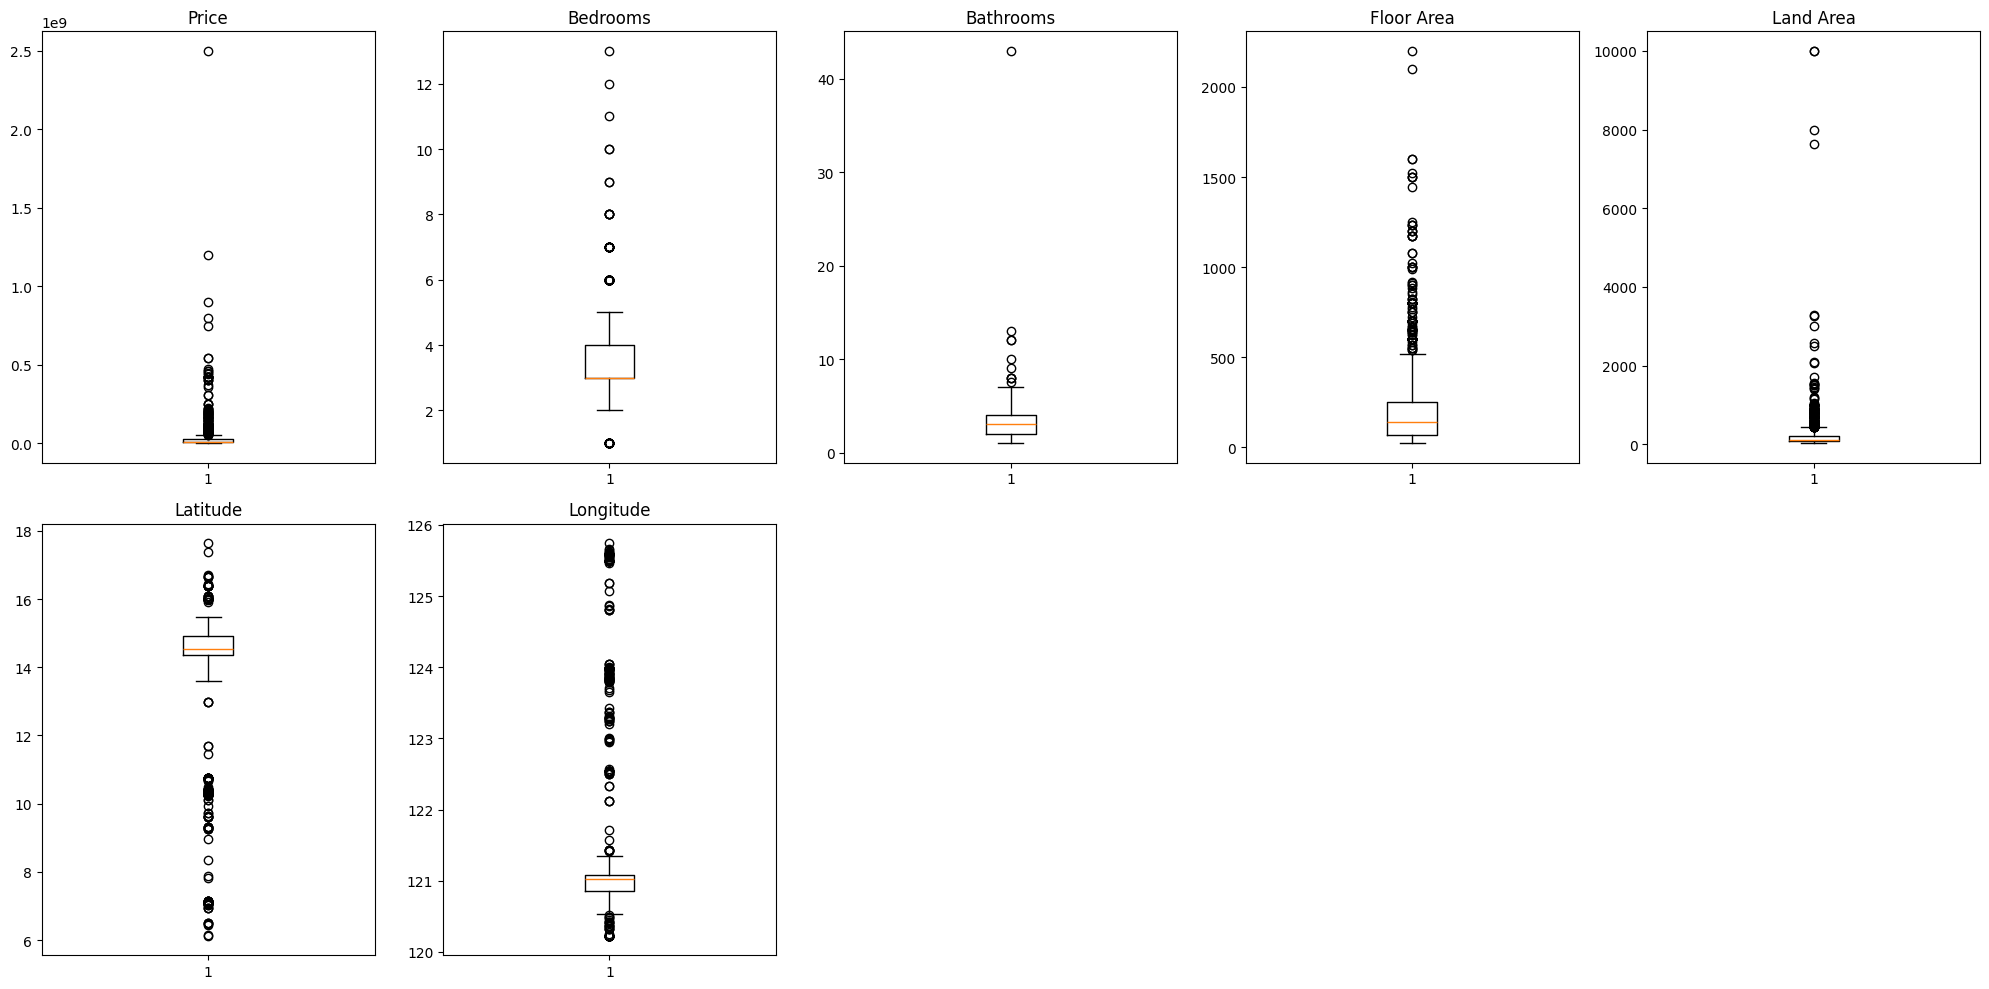

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

numeric_columns = df_clean.select_dtypes(include=["number"]).columns

plt.figure(figsize=(20, 10))

for i, column in enumerate(numeric_columns, start=1):
    plt.subplot(2, 5, i)
    plt.boxplot(df_clean[column])
    plt.title(column)

plt.tight_layout()
plt.show()

In [7]:
# Dropping certain observations for bathrooms and bedrooms due to outliers
initial_rows = df_clean.shape[0]

# Calculate IQR for Bedrooms
Q1_bed = df_clean['Bedrooms'].quantile(0.25)
Q3_bed = df_clean['Bedrooms'].quantile(0.75)
IQR_bed = Q3_bed - Q1_bed
lower_bed = Q1_bed - 1.5 * IQR_bed
upper_bed = Q3_bed + 1.5 * IQR_bed

# Calculate IQR for Bathrooms
Q1_bath = df_clean['Bathrooms'].quantile(0.25)
Q3_bath = df_clean['Bathrooms'].quantile(0.75)
IQR_bath = Q3_bath - Q1_bath
lower_bath = Q1_bath - 1.5 * IQR_bath
upper_bath = Q3_bath + 1.5 * IQR_bath

# Filter the dataframe
df_filtered = df_clean[
    (df_clean['Bedrooms'] >= lower_bed) & (df_clean['Bedrooms'] <= upper_bed) &
    (df_clean['Bathrooms'] >= lower_bath) & (df_clean['Bathrooms'] <= upper_bath)
]

final_rows = df_filtered.shape[0]

print(f"Initial rows (after dropna): {initial_rows}")
print(f"Bedrooms Bounds: [{lower_bed}, {upper_bed}]")
print(f"Bathrooms Bounds: [{lower_bath}, {upper_bath}]")
print(f"Final rows: {final_rows}")
print(f"Total Rows Removed: {initial_rows - final_rows}")

Initial rows (after dropna): 1320
Bedrooms Bounds: [1.5, 5.5]
Bathrooms Bounds: [-1.0, 7.0]
Final rows: 1220
Total Rows Removed: 100


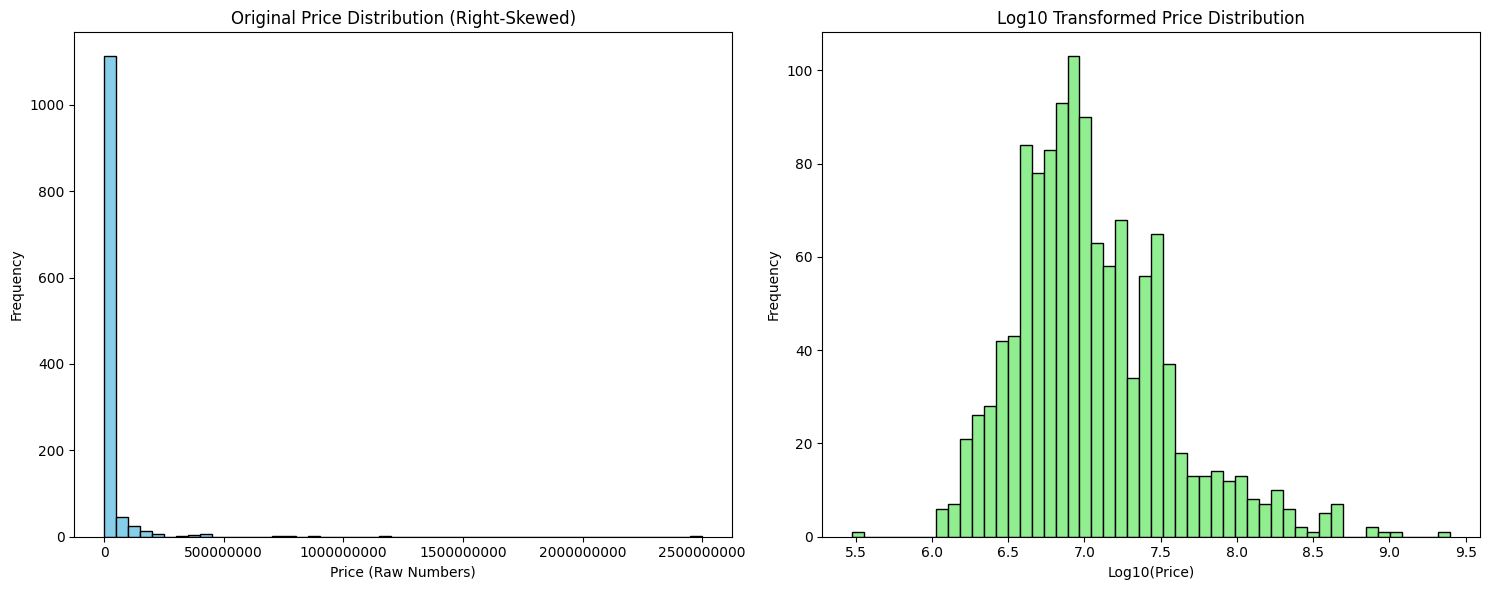

In [8]:
# Applying log transformation
df_filtered = df_filtered.copy()
df_filtered['Log_Price'] = np.log10(df_filtered['Price'])

# Visualize the Before and After
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram for Original Price
axes[0].hist(df_filtered['Price'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Original Price Distribution (Right-Skewed)')
axes[0].set_xlabel('Price (Raw Numbers)')
axes[0].set_ylabel('Frequency')
axes[0].ticklabel_format(style='plain', axis='x') # Prevents scientific notation

# Histogram for Log Transformed Price
axes[1].hist(df_filtered['Log_Price'], bins=50, color='lightgreen', edgecolor='black')
axes[1].set_title('Log10 Transformed Price Distribution')
axes[1].set_xlabel('Log10(Price)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

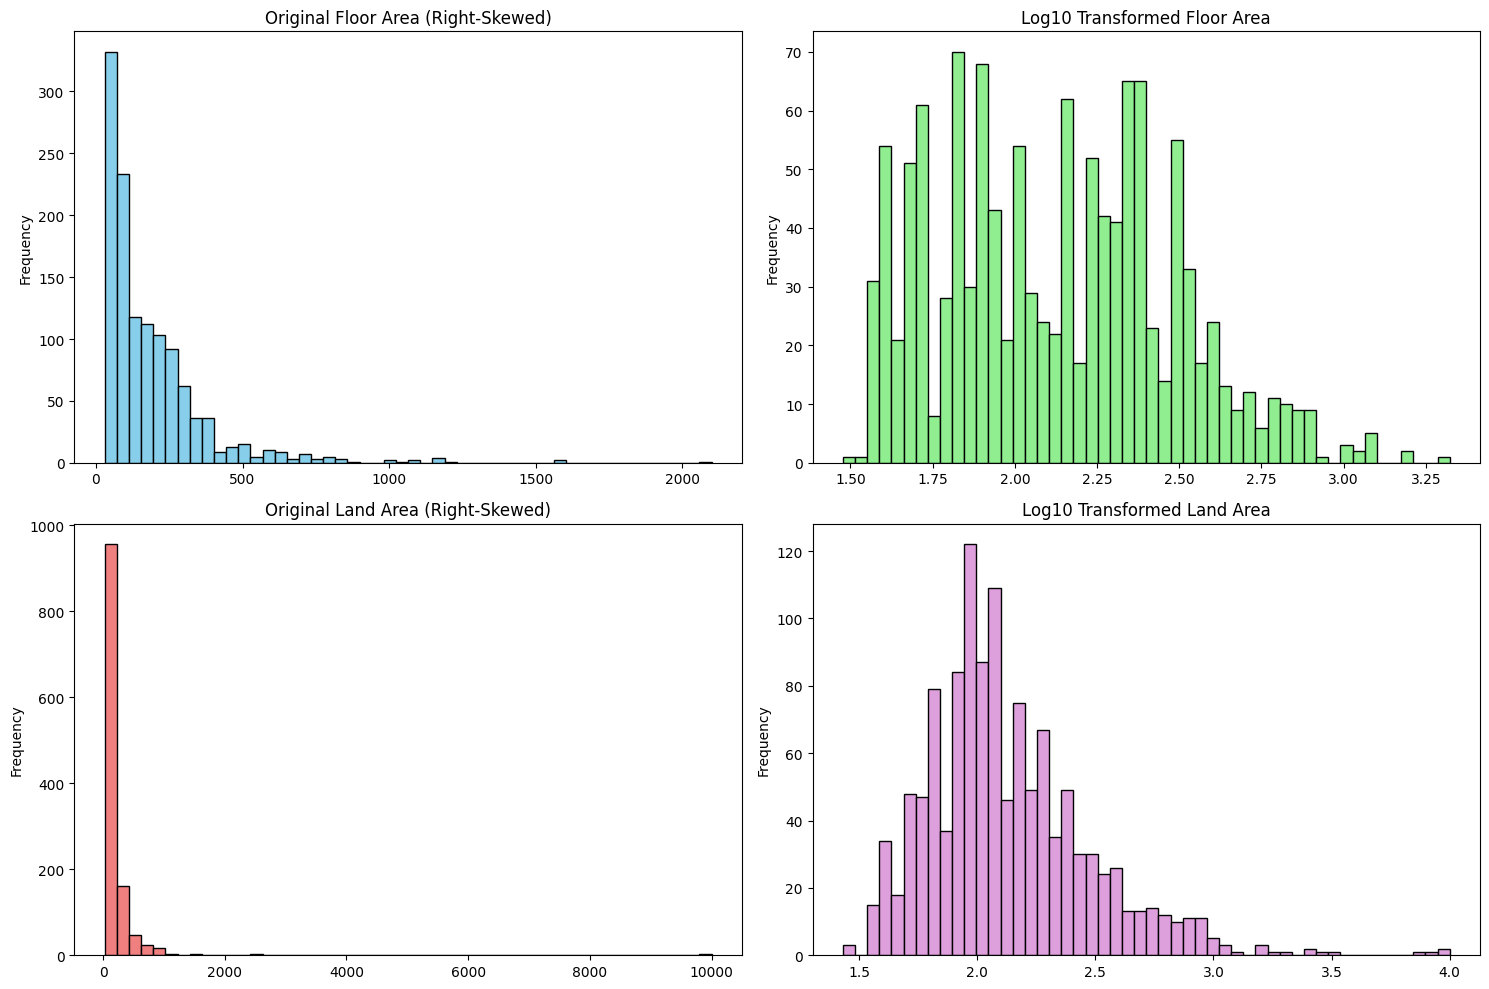

In [10]:
# Apply Log10 transformation to the Area features
df_filtered['Log_Floor_Area'] = np.log10(df_filtered['Floor Area'])
df_filtered['Log_Land_Area'] = np.log10(df_filtered['Land Area'])

# Drop the categorical variables to simplify the regression
df_filtered.drop(['Location', 'Description'], axis=1, inplace=True)

# Visualize the Area transformations (Before & After)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Floor Area Before
axes[0, 0].hist(df_filtered['Floor Area'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Original Floor Area (Right-Skewed)')
axes[0, 0].set_ylabel('Frequency')

# Floor Area After
axes[0, 1].hist(df_filtered['Log_Floor_Area'], bins=50, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Log10 Transformed Floor Area')
axes[0, 1].set_ylabel('Frequency')

# Land Area Before
axes[1, 0].hist(df_filtered['Land Area'], bins=50, color='lightcoral', edgecolor='black')
axes[1, 0].set_title('Original Land Area (Right-Skewed)')
axes[1, 0].set_ylabel('Frequency')

# Land Area After
axes[1, 1].hist(df_filtered['Log_Land_Area'], bins=50, color='plum', edgecolor='black')
axes[1, 1].set_title('Log10 Transformed Land Area')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

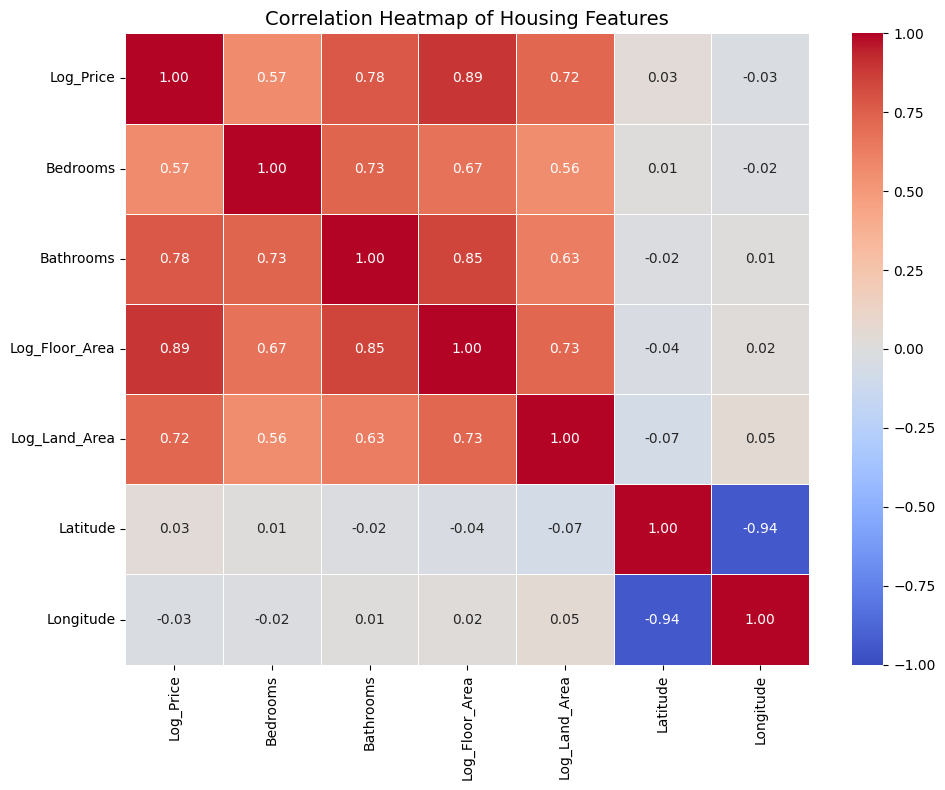

In [11]:
# Collinearity Check

import seaborn as sns
import matplotlib.pyplot as plt

# Select the final columns we want to evaluate
cols_for_corr = ['Log_Price', 'Bedrooms', 'Bathrooms', 'Log_Floor_Area', 'Log_Land_Area', 'Latitude', 'Longitude']

# Calculate the correlation matrix
corr_matrix = df_filtered[cols_for_corr].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Heatmap of Housing Features", fontsize=14)
plt.tight_layout()
plt.show()

## **Actual Modelling Here**

In [15]:
from sklearn.model_selection import train_test_split

# Assign to final_df for readability
final_df = df_filtered.copy()

# Clean out all raw/untransformed columns to prevent data leakage
cols_to_drop = ['Price', 'Floor Area', 'Land Area', 'Location', 'Description']
final_df = final_df.drop(columns=cols_to_drop, errors='ignore')

# Define Features (X) and Target (y)
X = final_df.drop('Log_Price', axis=1)
y = final_df['Log_Price']

# Perform the Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Master Metrics Tracker
model_results = {}

print(f"Features (X) shape: {X.shape}")
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
print(f"Active Features: {list(X.columns)}")
print("\nMaster dataset split and metrics tracker initialized. Ready for all models!")

Features (X) shape: (1220, 6)
Training data shape: (976, 6)
Testing data shape: (244, 6)
Active Features: ['Bedrooms', 'Bathrooms', 'Latitude', 'Longitude', 'Log_Floor_Area', 'Log_Land_Area']

Master dataset split and metrics tracker initialized. Ready for all models!


### **Multiple Linear Regression**

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Initialize and Train the Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make Predictions on the Test Set
lr_predictions = lr_model.predict(X_test)

# Calculate Metrics (Using sklearn's built-in MAE)
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_mse = mean_squared_error(y_test, lr_predictions)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_predictions)

# Store in Master Tracker
model_results['Linear Regression'] = {
    'MAE': lr_mae,
    'MSE': lr_mse,
    'RMSE': lr_rmse,
    'R2': lr_r2
}

# Print Model Summary
print("--- Linear Regression Summary ---")
print(f"Algorithm: Ordinary Least Squares (OLS)")
print(f"Number of Features: {X_train.shape[1]}")
print(f"Intercept (Base Log10 Price): {lr_model.intercept_:.4f}")
print("-" * 33)

# Print Performance Results
print("\n--- Linear Regression Performance ---")
print(f"R-squared (R²): {lr_r2:.4f}")
print(f"MAE:  {lr_mae:.4f}")
print(f"RMSE: {lr_rmse:.4f}")
print(f"MSE:  {lr_mse:.4f}")

# Display Coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\n--- Feature Coefficients ---")
print(coefficients.to_string(index=False))

--- Linear Regression Summary ---
Algorithm: Ordinary Least Squares (OLS)
Number of Features: 6
Intercept (Base Log10 Price): -5.0842
---------------------------------

--- Linear Regression Performance ---
R-squared (R²): 0.8234
MAE:  0.1543
RMSE: 0.2101
MSE:  0.0442

--- Feature Coefficients ---
       Feature  Coefficient
Log_Floor_Area     1.066123
 Log_Land_Area     0.276713
     Longitude     0.070603
      Latitude     0.056742
     Bathrooms     0.044668
      Bedrooms    -0.063101


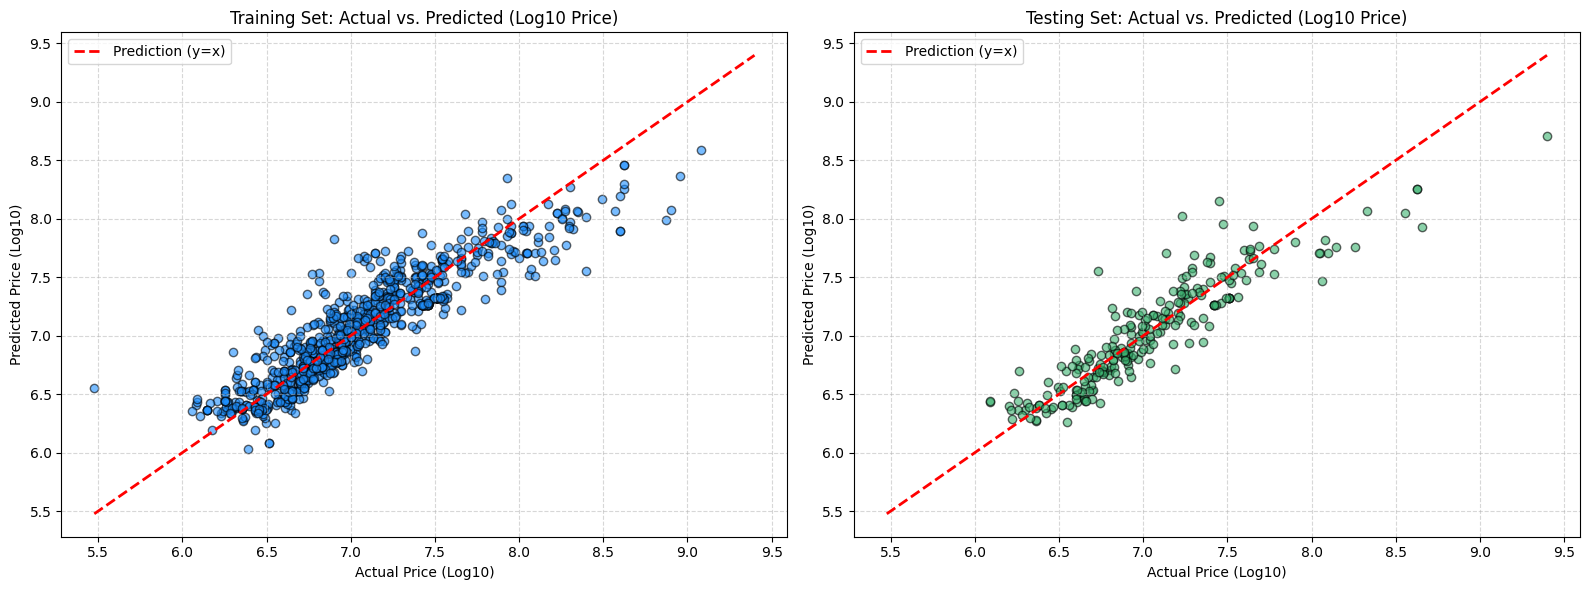

In [19]:
# 1. Generate predictions for the training set (we already have lr_predictions for test)
y_train_pred = lr_model.predict(X_train)

# 2. Set up the plotting area (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Define the bounds for the "Perfect Prediction" reference line
min_val = min(y.min(), y_train_pred.min(), lr_predictions.min())
max_val = max(y.max(), y_train_pred.max(), lr_predictions.max())

# --- Plot 1: Training Data ---
axes[0].scatter(y_train, y_train_pred, alpha=0.6, color='dodgerblue', edgecolor='k')
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Prediction (y=x)')
axes[0].set_title('Training Set: Actual vs. Predicted (Log10 Price)')
axes[0].set_xlabel('Actual Price (Log10)')
axes[0].set_ylabel('Predicted Price (Log10)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Plot 2: Testing Data ---
axes[1].scatter(y_test, lr_predictions, alpha=0.6, color='mediumseagreen', edgecolor='k')
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Prediction (y=x)')
axes[1].set_title('Testing Set: Actual vs. Predicted (Log10 Price)')
axes[1].set_xlabel('Actual Price (Log10)')
axes[1].set_ylabel('Predicted Price (Log10)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

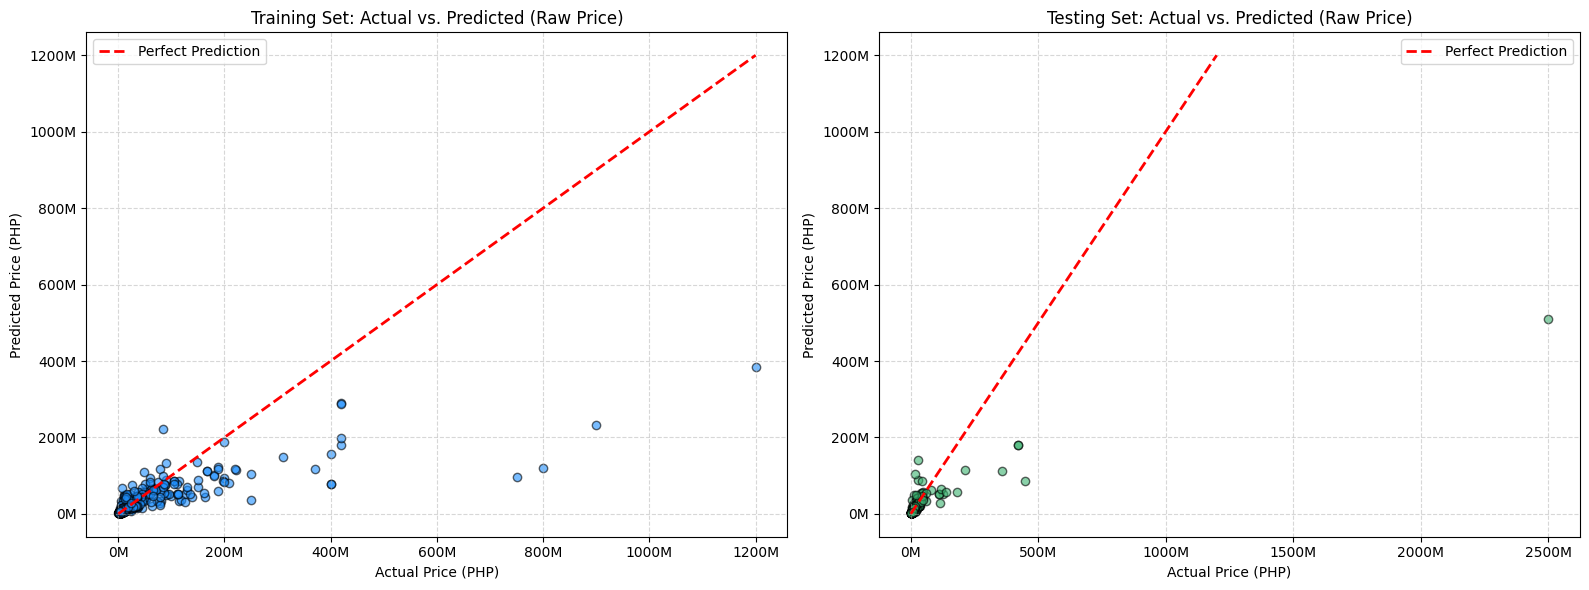

In [20]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# 1. Reverse the Log10 transformation for Actuals and Predictions
y_train_raw = 10 ** y_train
y_train_pred_raw = 10 ** y_train_pred

y_test_raw = 10 ** y_test
y_test_pred_raw = 10 ** lr_predictions

# 2. Set up the plotting area
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Define bounds for the reference line using the raw values
min_val = min(y_train_raw.min(), y_train_pred_raw.min(), y_test_pred_raw.min())
max_val = max(y_train_raw.max(), y_train_pred_raw.max(), y_test_pred_raw.max())

# Helper function to format axis labels into Millions (M)
def millions_formatter(x, pos):
    return f'{x / 1e6:.0f}M'

# --- Plot 1: Training Data (Raw) ---
axes[0].scatter(y_train_raw, y_train_pred_raw, alpha=0.6, color='dodgerblue', edgecolor='k')
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_title('Training Set: Actual vs. Predicted (Raw Price)')
axes[0].set_xlabel('Actual Price (PHP)')
axes[0].set_ylabel('Predicted Price (PHP)')
axes[0].xaxis.set_major_formatter(FuncFormatter(millions_formatter))
axes[0].yaxis.set_major_formatter(FuncFormatter(millions_formatter))
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Plot 2: Testing Data (Raw) ---
axes[1].scatter(y_test_raw, y_test_pred_raw, alpha=0.6, color='mediumseagreen', edgecolor='k')
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[1].set_title('Testing Set: Actual vs. Predicted (Raw Price)')
axes[1].set_xlabel('Actual Price (PHP)')
axes[1].set_ylabel('Predicted Price (PHP)')
axes[1].xaxis.set_major_formatter(FuncFormatter(millions_formatter))
axes[1].yaxis.set_major_formatter(FuncFormatter(millions_formatter))
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### **Polynomial Regression**

In [27]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# 1. Create Polynomial Features (Degree 2)
# We fit to the training data, then transform both train and test
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 2. Initialize and Train the Polynomial Regression Model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# 3. Make Predictions on the Test Set
poly_predictions = poly_model.predict(X_test_poly)

# 4. Calculate Metrics
poly_mae = mean_absolute_error(y_test, poly_predictions)
poly_mse = mean_squared_error(y_test, poly_predictions)
poly_rmse = np.sqrt(poly_mse)
poly_r2 = r2_score(y_test, poly_predictions)

# 5. Store in Master Tracker
model_results['Polynomial Regression (Deg 2)'] = {
    'MAE': poly_mae,
    'MSE': poly_mse,
    'RMSE': poly_rmse,
    'R2': poly_r2
}

# 6. Print Model Summary
print("--- Polynomial Regression Summary ---")
print(f"Algorithm: Linear Regression on Polynomial Features (Degree 2)")
print(f"Original Features: {X_train.shape[1]}")
print(f"Polynomial Expanded Features: {X_train_poly.shape[1]}")
print(f"Intercept (Base Log10 Price): {poly_model.intercept_:.4f}")
print("-" * 37)

# 7. Print Performance Results
print("\n--- Polynomial Regression Performance ---")
print(f"R-squared (R²): {poly_r2:.4f}")
print(f"MAE:  {poly_mae:.4f}")
print(f"RMSE: {poly_rmse:.4f}")
print(f"MSE:  {poly_mse:.4f}")

--- Polynomial Regression Summary ---
Algorithm: Linear Regression on Polynomial Features (Degree 2)
Original Features: 6
Polynomial Expanded Features: 27
Intercept (Base Log10 Price): 53.2610
-------------------------------------

--- Polynomial Regression Performance ---
R-squared (R²): 0.8497
MAE:  0.1329
RMSE: 0.1938
MSE:  0.0376


In [28]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# 1. Initialize and Train the Decision Tree Model
# We set random_state=42 for reproducibility. 
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# 2. Make Predictions on the Test Set
dt_predictions = dt_model.predict(X_test)

# 3. Calculate Metrics
dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_predictions)

# 4. Store in Master Tracker
model_results['Decision Tree'] = {
    'MAE': dt_mae,
    'MSE': dt_mse,
    'RMSE': dt_rmse,
    'R2': dt_r2
}

# 5. Print Model Summary
print("--- Decision Tree Summary ---")
print(f"Algorithm: CART (Classification and Regression Trees)")
print(f"Max Depth Reached: {dt_model.tree_.max_depth}")
print(f"Total Leaves: {dt_model.tree_.n_leaves}")
print("-" * 33)

# 6. Print Performance Results
print("\n--- Decision Tree Performance ---")
print(f"R-squared (R²): {dt_r2:.4f}")
print(f"MAE:  {dt_mae:.4f}")
print(f"RMSE: {dt_rmse:.4f}")
print(f"MSE:  {dt_mse:.4f}")

# 7. Display Feature Importances (replaces Coefficients)
dt_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- Feature Importances ---")
print(dt_importances.to_string(index=False))

--- Decision Tree Summary ---
Algorithm: CART (Classification and Regression Trees)
Max Depth Reached: 24
Total Leaves: 808
---------------------------------

--- Decision Tree Performance ---
R-squared (R²): 0.8290
MAE:  0.1257
RMSE: 0.2067
MSE:  0.0427

--- Feature Importances ---
       Feature  Importance
Log_Floor_Area    0.837197
 Log_Land_Area    0.066024
      Latitude    0.042993
     Longitude    0.038910
     Bathrooms    0.011487
      Bedrooms    0.003390


In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# 1. Initialize and Train the Random Forest Model
# n_estimators=100 means we are building an "ensemble" of 100 decision trees
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Make Predictions on the Test Set
rf_predictions = rf_model.predict(X_test)

# 3. Calculate Metrics
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_predictions)

# 4. Store in Master Tracker
model_results['Random Forest'] = {
    'MAE': rf_mae,
    'MSE': rf_mse,
    'RMSE': rf_rmse,
    'R2': rf_r2
}

# 5. Print Model Summary
print("--- Random Forest Summary ---")
print(f"Algorithm: Ensemble (Bagging)")
print(f"Number of Trees: {rf_model.n_estimators}")
print("-" * 31)

# 6. Print Performance Results
print("\n--- Random Forest Performance ---")
print(f"R-squared (R²): {rf_r2:.4f}")
print(f"MAE:  {rf_mae:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print(f"MSE:  {rf_mse:.4f}")

# 7. Display Feature Importances 
rf_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- Feature Importances ---")
print(rf_importances.to_string(index=False))

--- Random Forest Summary ---
Algorithm: Ensemble (Bagging)
Number of Trees: 100
-------------------------------

--- Random Forest Performance ---
R-squared (R²): 0.8930
MAE:  0.1052
RMSE: 0.1636
MSE:  0.0268

--- Feature Importances ---
       Feature  Importance
Log_Floor_Area    0.843062
 Log_Land_Area    0.065112
      Latitude    0.038310
     Longitude    0.034767
     Bathrooms    0.012795
      Bedrooms    0.005954
